1,house price predictor

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [5]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [6]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


2. comparing three models(linera regression,decsiontree,random forest)



In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
RMSE: 0.7455813830127764
R2: 0.5757877060324508


In [8]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("\nDecision Tree")
print("RMSE:", dt_rmse)
print("R2:", dt_r2)


Decision Tree
RMSE: 0.7037294974840077
R2: 0.622075845135081


In [9]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest")
print("RMSE:", rf_rmse)
print("R2:", rf_r2)


Random Forest
RMSE: 0.5053399773665033
R2: 0.8051230593157366


In [10]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

print(results)

               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1      Decision Tree  0.703729  0.622076
2      Random Forest  0.505340  0.805123


In [ ]:
3,feature importance visualisation

In [11]:
importance = rf.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_df)

      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


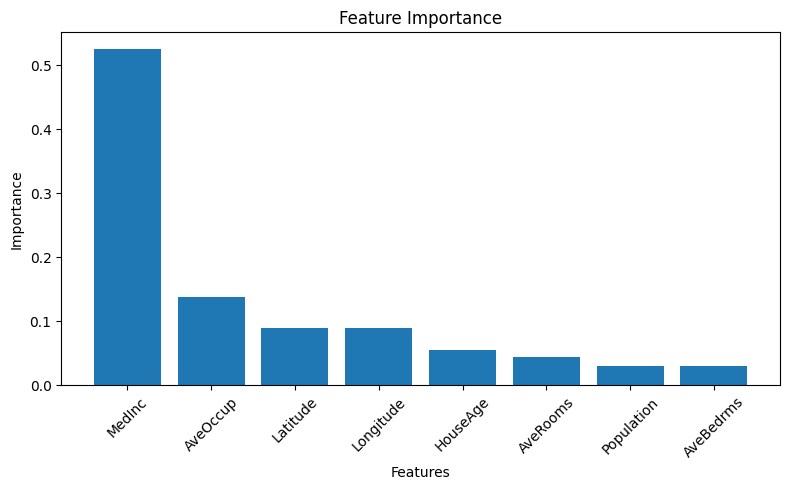

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_df["Feature"],
    feature_df["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

## Executive Summary: House Price Predictor

This project aimed to build a predictive model for house prices using the California Housing dataset. The process involved data loading, splitting the data into training and testing sets, and then evaluating three different regression models: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

### Model Performance:

The models were evaluated using Root Mean Squared Error (RMSE) and R-squared (R2) score. The results are summarized below:

| Model             | RMSE      | R2 Score  |
|:------------------|:----------|:----------|
| Linear Regression | 0.7456    | 0.5758    |
| Decision Tree     | 0.7037    | 0.6221    |
| **Random Forest** | **0.5053**| **0.8051**|

Among the three models, the **Random Forest Regressor** demonstrated the best performance, achieving the lowest RMSE of approximately **0.505** and the highest R2 score of approximately **0.805**. This indicates that the Random Forest model is capable of explaining about 80.5% of the variance in house prices and provides the most accurate predictions compared to Linear Regression and Decision Tree models.

### Feature Importance:

An analysis of feature importance from the Random Forest model revealed the following key drivers of house prices:

*   **Median Income (MedInc)**: This was by far the most important feature, highlighting that the economic prosperity of an area is a significant determinant of house values.
*   **Average Occupancy (AveOccup)**: This feature also played a substantial role, suggesting that population density or household size within a block group influences house prices.
*   **Latitude and Longitude**: Geographic location (latitude and longitude) were also important, which is expected as different regions in California have varying housing markets and desirability.

### Conclusion:

The Random Forest model proved to be the most effective in predicting house prices in California, largely driven by features like median income and geographic location. Further improvements could potentially be achieved through hyperparameter tuning, more extensive feature engineering, or exploring other advanced ensemble methods.